
# ATM Cash Withdrawal Prediction Using ANN (Regression)

## Problem Statement
The objective of this project is to build an Artificial Neural Network (ANN) regression model to predict the total amount withdrawn from an ATM using historical transaction data, temporal features, and previous withdrawal trends.

Since the target variable `total_amount_withdrawn` is continuous, this is a Regression problem (not classification).


In [1]:

# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [2]:

# Step 2: Load Dataset
df = pd.read_csv('ATM.csv')
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (2244, 11)


,id,atm_name,weekday,festival_religion,working_day,holiday_sequence,trans_date_set,trans_month,trans_year,prevweek_mean,total_amount_withdrawn
0,11,Mount Road ATM,MONDAY,NH,W,WWW,1,1,2011,648600,897100
1,16,Mount Road ATM,TUESDAY,NH,W,WWW,1,1,2011,648600,826000
2,21,Mount Road ATM,WEDNESDAY,NH,W,WWW,1,1,2011,648600,754400
3,26,Mount Road ATM,THURSDAY,NH,W,WWW,2,1,2011,648600,834200
4,31,Mount Road ATM,FRIDAY,NH,W,WWW,2,1,2011,648600,575300


In [3]:

# Step 3: Exploratory Data Analysis (EDA)
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2244 entries, 0 to 2243
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      2244 non-null   int64 
 1   atm_name                2244 non-null   object
 2   weekday                 2244 non-null   object
 3   festival_religion       2244 non-null   object
 4   working_day             2244 non-null   object
 5   holiday_sequence        2244 non-null   object
 6   trans_date_set          2244 non-null   int64 
 7   trans_month             2244 non-null   int64 
 8   trans_year              2244 non-null   int64 
 9   prevweek_mean           2244 non-null   int64 
 10  total_amount_withdrawn  2244 non-null   int64 
dtypes: int64(6), object(5)
memory usage: 193.0+ KB


,id,trans_date_set,trans_month,trans_year,prevweek_mean,total_amount_withdrawn
count,2244.000000,2244.000000,2244.000000,2244.000000,2.244000e+03,2.244000e+03
mean,5706.037433,3.557932,6.313280,2013.710784,5.150901e+05,5.157175e+05
std,3348.296502,1.760703,3.257336,1.920082,1.935272e+05,2.551791e+05
min,11.000000,1.000000,1.000000,2011.000000,1.800000e+03,1.000000e+02
25%,2816.750000,2.000000,4.000000,2012.000000,4.197290e+05,3.494750e+05
50%,5664.500000,4.000000,6.000000,2014.000000,5.403860e+05,5.141000e+05
75%,8447.250000,5.000000,9.000000,2015.000000,6.378000e+05,6.849250e+05
max,11585.000000,7.000000,12.000000,2017.000000,1.006829e+06,1.410700e+06


In [4]:

# Step 4: Check Missing Values
df.isnull().sum()


id                        0
atm_name                  0
weekday                   0
festival_religion         0
working_day               0
holiday_sequence          0
trans_date_set            0
trans_month               0
trans_year                0
prevweek_mean             0
total_amount_withdrawn    0
dtype: int64


## Feature Engineering
- Dropping 'atm_name' column because it has only one constant value.
- Dropping 'id' column as it does not contribute to prediction.
- Encoding categorical columns using Label Encoding.


In [5]:

# Step 5: Drop Irrelevant Columns
df = df.drop(['atm_name', 'id'], axis=1)
df.head()


,weekday,festival_religion,working_day,holiday_sequence,trans_date_set,trans_month,trans_year,prevweek_mean,total_amount_withdrawn
0,MONDAY,NH,W,WWW,1,1,2011,648600,897100
1,TUESDAY,NH,W,WWW,1,1,2011,648600,826000
2,WEDNESDAY,NH,W,WWW,1,1,2011,648600,754400
3,THURSDAY,NH,W,WWW,2,1,2011,648600,834200
4,FRIDAY,NH,W,WWW,2,1,2011,648600,575300


In [6]:

# Step 6: Encode Categorical Features
categorical_cols = ['weekday', 'festival_religion', 'working_day', 'holiday_sequence']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,weekday,festival_religion,working_day,holiday_sequence,trans_date_set,trans_month,trans_year,prevweek_mean,total_amount_withdrawn
0,1,4,1,7,1,1,2011,648600,897100
1,5,4,1,7,1,1,2011,648600,826000
2,6,4,1,7,1,1,2011,648600,754400
3,4,4,1,7,2,1,2011,648600,834200
4,0,4,1,7,2,1,2011,648600,575300


In [7]:

# Step 7: Define Features and Target
X = df.drop('total_amount_withdrawn', axis=1)
y = df['total_amount_withdrawn']


In [8]:

# Step 8: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (1795, 8)
Testing Shape: (449, 8)


In [9]:

# Step 9: Feature Scaling (Important for ANN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#### The dataset shows temporal patterns in ATM withdrawals influenced by working days, festivals, and previous week mean withdrawals. The target variable is continuous and slightly right-skewed, confirming suitability for regression modeling


## ANN Model (Regression)
- Hidden Layers: ReLU activation
- Output Layer: Linear activation (Correct for Regression Problems)


In [10]:

# Step 10: Build ANN Regression Model
model = Sequential()

model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

# Correct Output Layer for Regression
model.add(Dense(1, activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()


C:\Users\sneha\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Step 11: Train the Model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)
import pandas as pd

# Convert training history to dataframe
history_df = pd.DataFrame(history.history)

# Save CSV file
history_df.to_csv("history.csv", index=False)

print("history.csv created successfully!")

# Step 12: Save the trained model
# Best modern format (fixes InputLayer error)
model.save("model.keras")
print("Model saved in .keras format successfully!")


import pickle

with open("training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved!")

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 42715541504.0000 - mae: 161056.0781 - val_loss: 43424550912.0000 - val_mae: 164381.5781
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 42339721216.0000 - mae: 159844.2969 - val_loss: 43467042816.0000 - val_mae: 164552.6406
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 41558687744.0000 - mae: 159455.0312 - val_loss: 43550253056.0000 - val_mae: 164649.8438
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 42907041792.0000 - mae: 161417.4844 - val_loss: 43484135424.0000 - val_mae: 164497.2969
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 42718056448.0000 - mae: 160833.0625 - val_loss: 43423350784.0000 - val_mae: 164378.1562
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 43307548672.0000 - mae: 161661.5000 - val_loss: 43423244288.0000 - val_mae: 164431.3906
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 42989658112.0000 - mae: 162970.4219 - val_loss: 43314368512.0000 -

In [17]:
import pickle

# Save the trained scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaler saved as scaler.pkl")

Scaler saved as scaler.pkl


In [12]:

# Step 13: Model Evaluation
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
MAE: 163870.55659277563
MSE: 43412666485.70795
RMSE: 208357.0648807185
R2 Score: 0.298332154750824


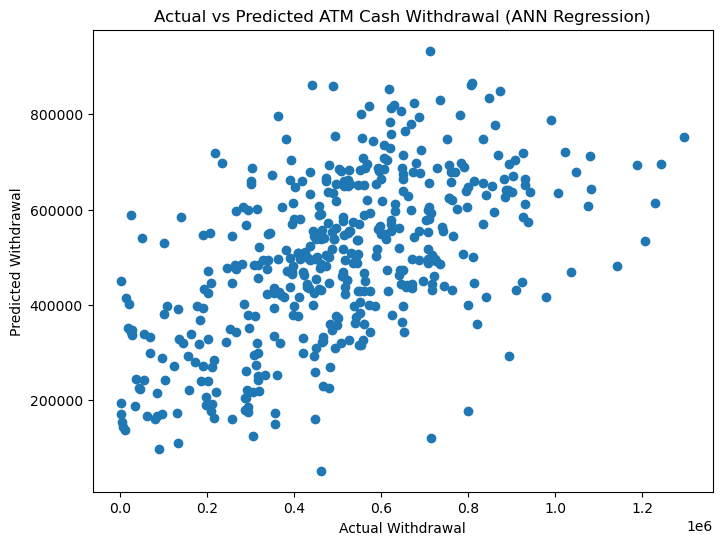

In [13]:

# Step 13: Actual vs Predicted Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Withdrawal")
plt.ylabel("Predicted Withdrawal")
plt.title("Actual vs Predicted ATM Cash Withdrawal (ANN Regression)")
plt.show()


## 📌 Conclusion

The ANN regression model was developed to predict ATM cash withdrawal amounts using historical and temporal features.

The model was evaluated using MAE, MSE, RMSE, and R². The current model achieved an R² score of approximately 0.30, indicating that there is scope for further improvement in prediction performance.

Future improvements can include hyperparameter tuning, feature engineering, and comparing the ANN with other regression algorithms.